In [13]:
import pandas as pd

In [18]:
CSV_PATH = "../data/draws_clean.csv"

# Replace the column names 
column_names = [
    "draw_number", "draw_date",
    "main_1", "main_2", "main_3", "main_4", "main_5" ,"main_6",
    "bouns", "powerball"
]

# header=0 means the original header row
# names=column_names means throw away those original header names and use mine instead
df = pd.read_csv(CSV_PATH, header=0, names=column_names)

# Shape gives us the number of rows and columns
print(df.shape)

# Head gives us the first 5 rows
df.head()

(1520, 10)


,draw_number,draw_date,main_1,main_2,main_3,main_4,main_5,main_6,bouns,powerball
0,2593,2026-06-10,2,7,12,17,21,37,35,6
1,2592,2026-06-06,3,22,29,37,39,40,13,1
2,2591,2026-06-03,1,4,9,11,13,36,24,9
3,2590,2026-05-30,8,10,29,35,36,39,3,3
4,2589,2026-05-27,6,17,19,21,27,32,28,10


In [19]:





df["draw_date"] = pd.to_datetime(df["draw_date"])

df = df.sort_values("draw_date").reset_index(drop=True)

print(df["draw_date"].dtype)
print("Oldest:", df["draw_date"].min())
print("Newest:", df["draw_date"].max())
df.head()

datetime64[us]
Oldest: 2008-01-05 00:00:00
Newest: 2026-06-10 00:00:00


,draw_number,draw_date,main_1,main_2,main_3,main_4,main_5,main_6,bouns,powerball
0,1074,2008-01-05,3,8,14,18,21,36,35,3
1,1075,2008-01-12,5,14,16,19,22,40,33,9
2,1076,2008-01-19,8,10,12,26,36,38,21,5
3,1077,2008-01-26,10,15,19,22,34,40,17,4
4,1078,2008-02-02,2,4,12,22,32,38,20,8


In [20]:
# Faltten all main number columns into the 1D array for counting easier

main_cols = ["main_1", "main_2", "main_3", "main_4", "main_5", "main_6", "bouns"]

# df[main_cols] passing a list of column from the df[main_cols]. 1520 rows and 7 column table.
# .values is that convers the pandas table into a numpy array (raw data).
# .flatten() reshapes the data from 2D to 1D.
all_main_numbers = df[main_cols].values.flatten()

# len() counts the number of elements in the array.
print(f"Total number draws to counts: {len(all_main_numbers)}")

Total number draws to counts: 10640


1     275
2     271
3     254
4     250
5     264
6     259
7     261
8     231
9     255
10    294
11    264
12    278
13    289
14    243
15    289
16    257
17    293
18    265
19    296
20    258
21    270
22    279
23    290
24    275
25    278
26    257
27    250
28    263
29    262
30    261
31    271
32    271
33    253
34    257
35    270
36    248
37    262
38    259
39    236
40    282
Name: count, dtype: int64


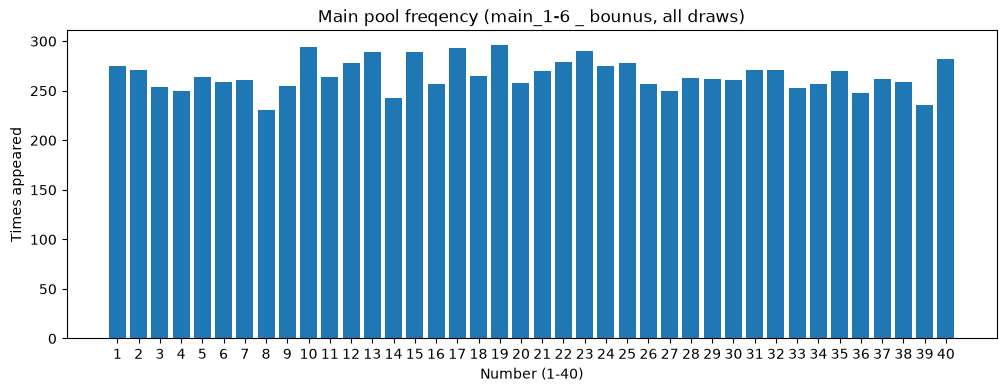

'\nprint("Top 3 most frequent:")\nreorder by count, highest first\nprint(freq.sort_values(ascending=False).head(3))\n\nprint("Bottom 3 least frequent:")\nreorder by count, lowest first\nprint(freq.sort_values(ascending=True).head(3))\n\n'

In [38]:
# Takes all_main_numbers from cell4 and counts how many times each number(1-40) apperaed.

import pandas as pd
import matplotlib.pyplot as plt

# pd.Series(all_main_numbers) is wraps it back into a pandas Series(single-column table.)
# .value_counts() counts the number of occurences of each number.
# .sort_index() sorts the numbers by their index.(easier to read.)
freq = pd.Series(all_main_numbers).value_counts().sort_index()

print(freq)

plt.figure(figsize=(12, 4))
plt.bar(freq.index, freq.values)
plt.xlabel("Number (1-40)")
plt.ylabel("Times appeared")
plt.title("Main pool freqency (main_1-6 _ bounus, all draws)")
plt.xticks(range(1, 41)) # Show every number 1-40 on the x-axis
plt.tight_layout() # Make sure the plot is not cut off
plt.show()
# Practice 
'''
print("Top 3 most frequent:")
reorder by count, highest first
print(freq.sort_values(ascending=False).head(3))

print("Bottom 3 least frequent:")
reorder by count, lowest first
print(freq.sort_values(ascending=True).head(3))

'''

powerball
1     162
2     172
3     152
4     138
5     165
6     150
7     139
8     157
9     136
10    149
Name: count, dtype: int64


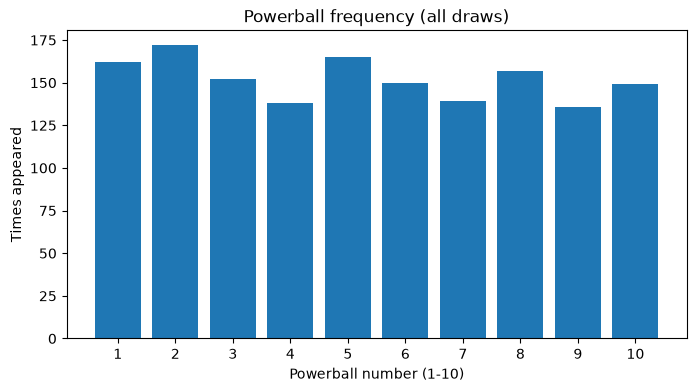

In [40]:
# Powerball frequency

pb_freq = df["powerball"].value_counts().sort_index()

print(pb_freq)

plt.figure(figsize=(8, 4))
plt.bar(pb_freq.index, pb_freq.values)
plt.xlabel("Powerball number (1-10)")
plt.ylabel("Times appeared")
plt.title("Powerball frequency (all draws)")
plt.xticks(range(1, 11))
plt.show()